In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
from sklearn.cluster import KMeans

## 請安裝
> pip install opencv-python

# Problem : K-Means Clustering
**K-Means Clustering** is an unsupervised learning algorithm for data grouping. In image segmen- tation, it can be applied to partition image pixels into different groups based on the associated pixel values or features. In this problem, you will learn how to segment the provided image by using K-means clustering.

In [2]:
img = cv2.imread('data/bird.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

## 1-1. cluster with only RGB values

In [3]:
def km_clust(array, n_clusters, sample_size=20000):
    array = np.asarray(array, dtype=np.float32)

    # Fit on a deterministic sample, then predict every pixel.
    # This keeps the 1024x1024 image runnable while still segmenting the full image.
    if len(array) > sample_size:
        rng = np.random.default_rng(0)
        sample_index = rng.choice(len(array), size=sample_size, replace=False)
        fit_array = array[sample_index]
    else:
        fit_array = array

    k_m = KMeans(n_clusters=n_clusters, random_state=0, n_init=10)
    k_m.fit(fit_array)

    center = k_m.cluster_centers_
    label = k_m.predict(array)
    return label, center

Exception in thread Thread-4 (_readerthread):
Traceback (most recent call last):
  File "C:\Users\Lin\AppData\Local\Programs\Python\Python313\Lib\threading.py", line 1043, in _bootstrap_inner
    self.run()
    ~~~~~~~~^^
  File "C:\Users\Lin\AppData\Local\Programs\Python\Python313\Lib\threading.py", line 994, in run
    self._target(*self._args, **self._kwargs)
    ~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Lin\AppData\Local\Programs\Python\Python313\Lib\subprocess.py", line 1615, in _readerthread
    buffer.append(fh.read())
                  ~~~~~~~^^
UnicodeDecodeError: 'cp950' codec can't decode byte 0xe6 in position 18: illegal multibyte sequence


C:\Users\Lin\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\Lin\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\backend\context.py", line 255, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


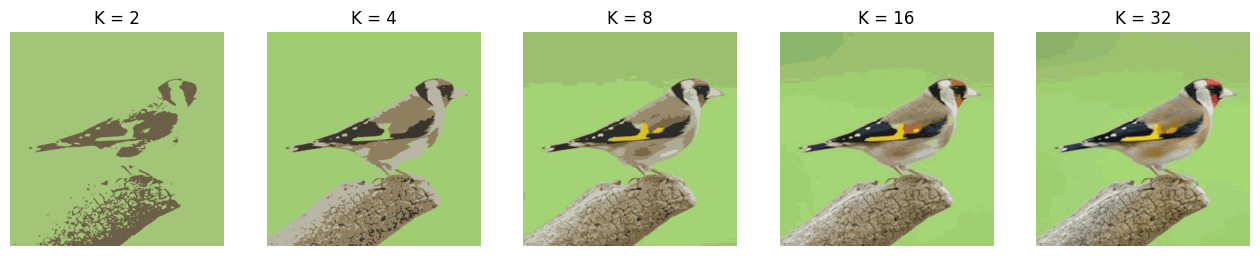

In [4]:
Z_rgb = img.reshape((-1, 3))
Ks = [2, 4, 8, 16, 32]
plt.figure(figsize=(16, 12))

for i, K in enumerate(Ks):
    label, center = km_clust(Z_rgb, K)

    center = np.uint8(center)
    res = center[label.flatten()]
    res = res.reshape(img.shape)

    plt.subplot(1, 5, i + 1)
    plt.axis('off')
    plt.title('K = {}'.format(K))
    plt.imshow(res)

plt.show()

## 1-2. cluster with RGB values and the location

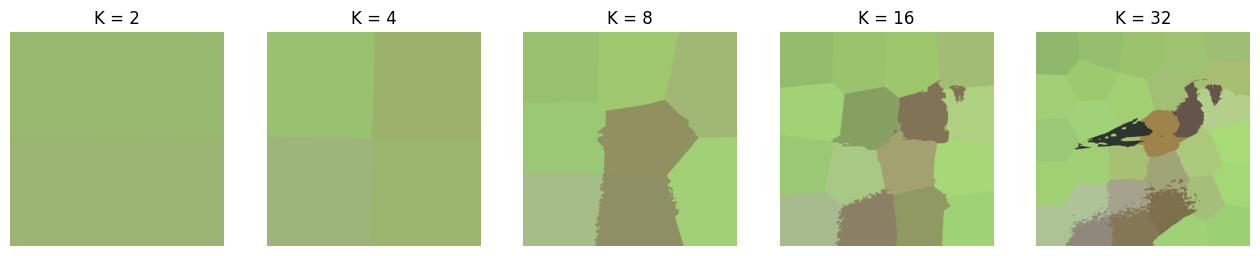

In [5]:
height, width, channels = img.shape
rows, cols = np.indices((height, width))

# Added location feature: RGB + row + column
Z = np.dstack((img, rows, cols)).reshape(-1, channels + 2)

Ks = [2, 4, 8, 16, 32]
plt.figure(figsize=(16, 12))

for i, K in enumerate(Ks):
    label, center = km_clust(Z, K)

    center = np.uint8(center[:, :3])
    res = center[label.flatten()]
    res = res.reshape(img.shape)

    plt.subplot(1, 5, i + 1)
    plt.axis('off')
    plt.title('K = {}'.format(K))
    plt.imshow(res)

plt.show()

## 1-3. explain the differences between the two methods under the same K.
![](images/7.4_result.PNG)

RGB-only clustering uses color values only, so pixels with similar colors are grouped together even when they are far apart in the image. This can make separate regions merge and can leave small noisy patches.

RGB + location clustering uses color plus each pixel's row and column, so nearby pixels are more likely to stay in the same cluster. Under the same K, the result is usually more spatially coherent and the object/background regions are clearer, but location can also dominate if its scale is much larger than RGB values.

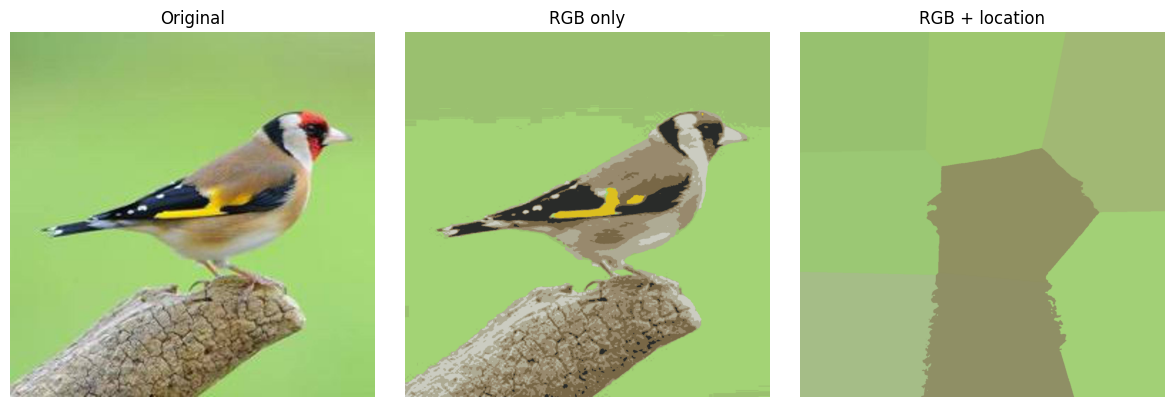

In [6]:
K = 8
Z_rgb = img.reshape((-1, 3))
label_rgb, center_rgb = km_clust(Z_rgb, K)
seg_rgb = np.uint8(center_rgb)[label_rgb].reshape(img.shape)

height, width, channels = img.shape
rows, cols = np.indices((height, width))
Z_rgb_xy = np.dstack((img, rows, cols)).reshape(-1, channels + 2)
label_xy, center_xy = km_clust(Z_rgb_xy, K)
seg_rgb_xy = np.uint8(center_xy[:, :3])[label_xy].reshape(img.shape)

plt.figure(figsize=(12, 4))
for i, (title, image) in enumerate([
    ('Original', img),
    ('RGB only', seg_rgb),
    ('RGB + location', seg_rgb_xy),
]):
    plt.subplot(1, 3, i + 1)
    plt.axis('off')
    plt.title(title)
    plt.imshow(image)

plt.tight_layout()
plt.show()